In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error    

In [2]:
df=pd.read_csv("C:/Users/phadt/ML Projects/Alogrithmic Models/Ridge and Lasso Regression Model/Student_performance_10k.csv")

In [4]:
print("Shape")
print(df.shape)

print("\nInfo")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

print("\nStatistics")
print(df.describe(include="all"))

print("\nCorrelation")
print(df.corr(numeric_only=True))

Shape
(10000, 12)

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   object 
 1   gender                       9982 non-null   object 
 2   race_ethnicity               9977 non-null   object 
 3   parental_level_of_education  9978 non-null   object 
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9976 non-null   object 
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   object 
dtypes: float64(6), object(6)
memory usage: 937.6+ KB

M

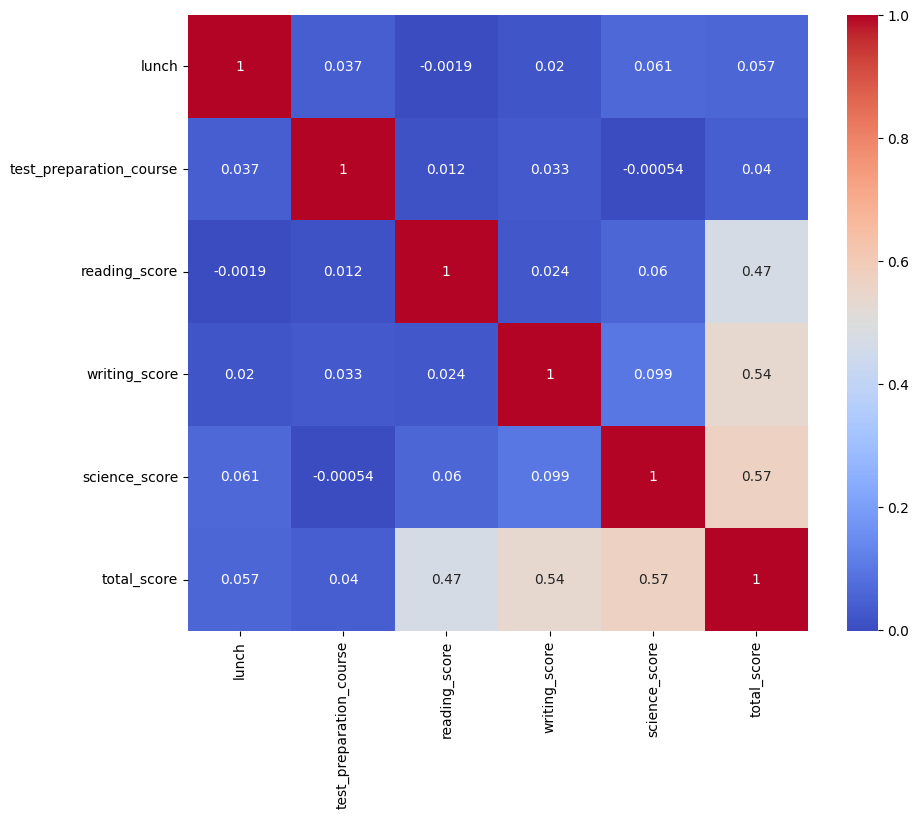

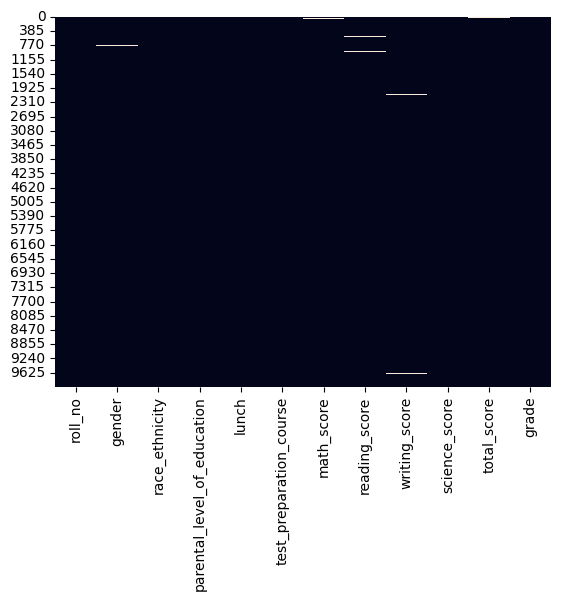

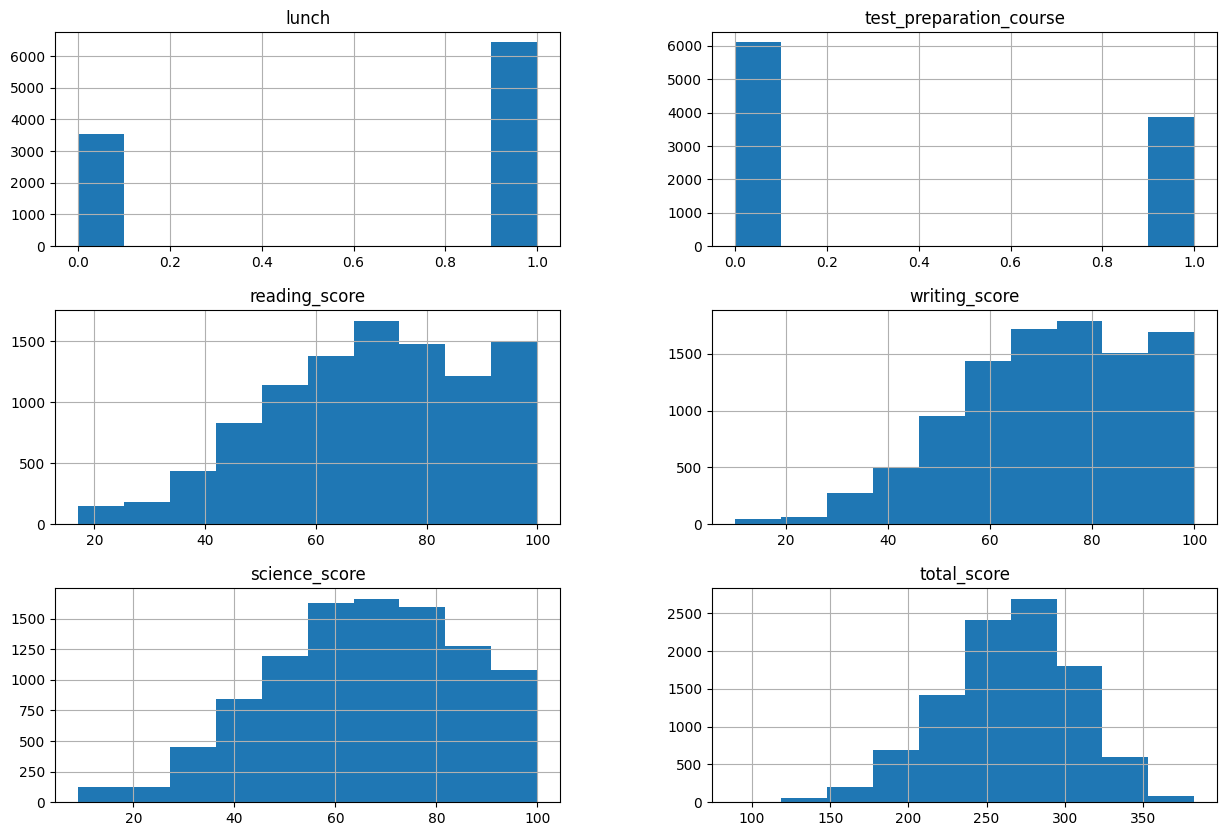

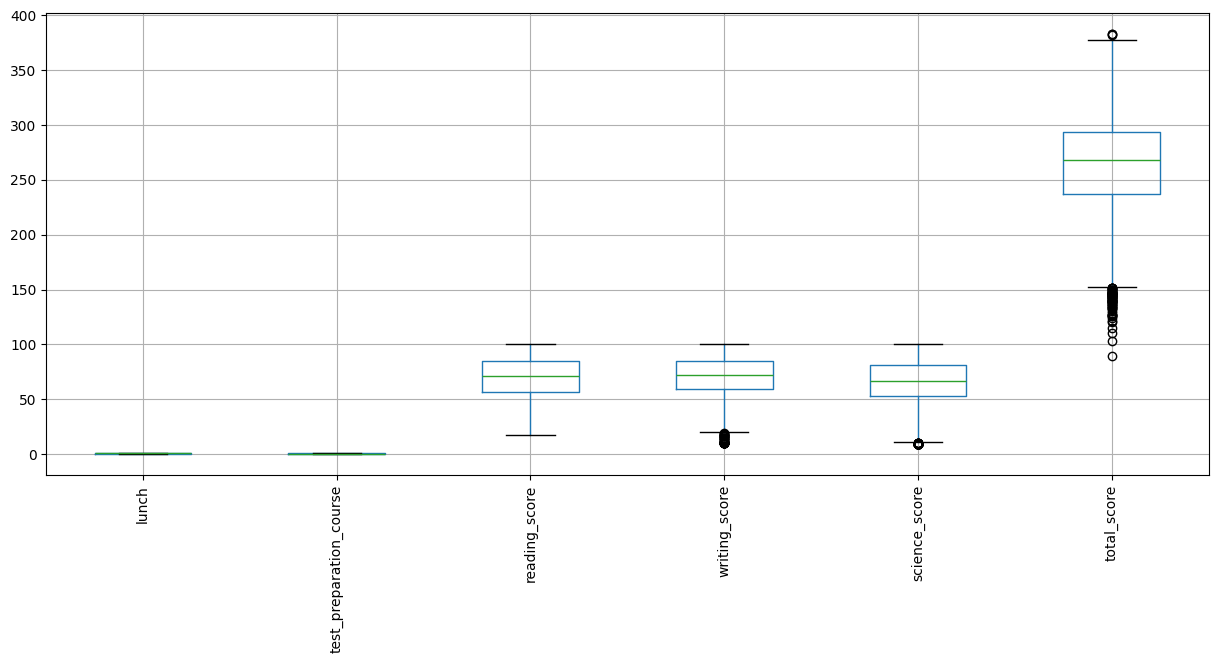

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Missing values
sns.heatmap(df.isnull(), cbar=False)
plt.show()

# Histograms
df.hist(figsize=(15,10))
plt.show()

# Boxplots
df.boxplot(figsize=(15,6))
plt.xticks(rotation=90)
plt.show()

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop(columns=["roll_no"], inplace=True)

In [9]:
df.dtypes

gender                          object
race_ethnicity                  object
parental_level_of_education     object
lunch                          float64
test_preparation_course        float64
math_score                      object
reading_score                  float64
writing_score                  float64
science_score                  float64
total_score                    float64
grade                           object
dtype: object

In [10]:
score_cols = [
    "math_score",
    "reading_score",
    "writing_score",
    "science_score",
    "total_score"
]

for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [11]:
df.isnull().sum()

gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     25
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64

In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\phadt\AppData\Local\Temp\ipykernel_33884\99452248.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [13]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\phadt\AppData\Local\Temp\ipykernel_33884\4282419667.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
science_score                  0
total_score                    0
grade                          0
dtype: int64

In [15]:
X = df.drop(["total_score", "grade"], axis=1)

y = df["total_score"]

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [17]:
X.head()

,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,gender_Girl,gender_\tmale,gender_female,gender_male,...,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group C\n,race_ethnicity_group D,race_ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school
0,1.0,1.0,89.0,38.0,85.0,26.0,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False
1,1.0,0.0,65.0,100.0,67.0,96.0,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
2,1.0,0.0,10.0,99.0,97.0,58.0,False,False,False,True,...,False,True,False,False,False,False,False,True,False,False
3,1.0,1.0,22.0,51.0,41.0,84.0,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False
4,0.0,1.0,26.0,58.0,64.0,65.0,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False


In [18]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## Scale Features


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [21]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [22]:
ridge_pred = ridge.predict(X_test)


In [23]:
print("MAE :", mean_absolute_error(y_test, ridge_pred))

print("MSE :", mean_squared_error(y_test, ridge_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, ridge_pred)))

print("R2 :", r2_score(y_test, ridge_pred))

MAE : 0.31128007290444776
MSE : 7.193573451913823
RMSE : 2.6820837891299782
R2 : 0.9959855863295154


In [24]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [25]:
lasso_pred = lasso.predict(X_test)

## model Evaluation

In [26]:
print("MAE :", mean_absolute_error(y_test, lasso_pred))

print("MSE :", mean_squared_error(y_test, lasso_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lasso_pred)))

print("R2 :", r2_score(y_test, lasso_pred))

MAE : 0.3940037738648898
MSE : 7.216708744753782
RMSE : 2.6863932595124234
R2 : 0.9959726755506837


In [28]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": ridge_pred
})

comparison.head(10)

,Actual,Predicted
0,332.0,331.787928
1,234.0,234.129776
2,211.0,211.256602
3,182.0,182.292446
4,310.0,309.716440
5,247.0,247.106807
6,291.0,290.820149
7,320.0,319.977215
8,293.0,293.169924
9,309.0,308.896436


In [ ]:
comparison_lasso = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lasso_pred
})

## Scatter PLot


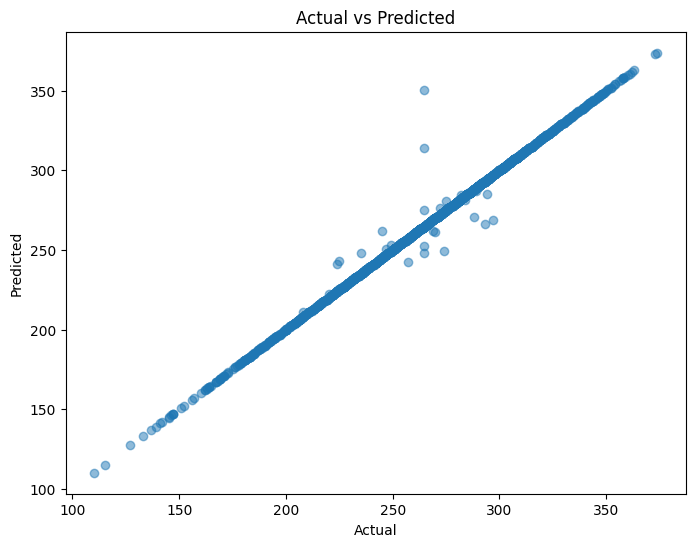

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, ridge_pred, alpha=0.5)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

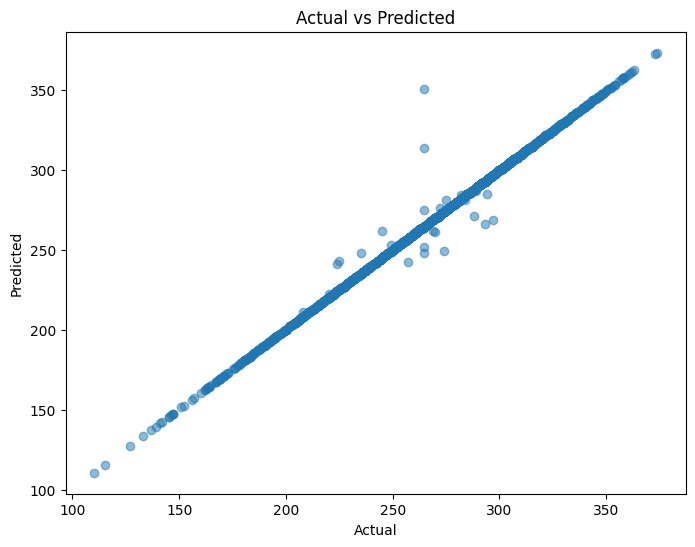

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, lasso_pred, alpha=0.5)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

## Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

parameters = {
    "alpha": [0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    Ridge(),
    parameters,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 10}
0.9970140723014813


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

parameters = {
    "alpha":[0.001,0.01,0.1,1,10]
}

grid = GridSearchCV(
    Lasso(),
    parameters,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

c:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.309467e+03, tolerance: 1.146e+03
  model = cd_fast.enet_coordinate_descent(
c:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.233060e+03, tolerance: 1.138e+03
  model = cd_fast.enet_coordinate_descent(
c:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.132301e+03, tolerance: 1.128e+03
  model = cd_f

{'alpha': 0.01}
0.9970191070920371


## Saving the Model

In [37]:
import joblib

joblib.dump(ridge_pred, "ridge_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [38]:
import joblib

joblib.dump(lasso_pred, "lasso_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']